# Merchant retention for a virtual card program

A payments program converts merchants from paper check to a single-use account (SUA) virtual card. Leadership wants one number that says whether the program is working: the North Star Metric (NSM), defined here as the share of SUA volume retained over a 3-month window. This notebook rebuilds that measurement end to end in SQL.

What the notebook does:

1. **Turns field-level change data capture (CDC) into enrollment history**: deduplicates a change log, pairs each join with its following churn, and unions in a manual backfill that never hit the log.
2. **Reports monthly program movement**: beginning-of-month (BOM), joined, churned, end-of-month (EOM) merchant counts, and reads the story in the chart (an outreach campaign, its wrongful conversions, a manual churn batch).
3. **Builds two mart tables** the way the production version did with dbt, because the original ran on Amazon Athena with a 100 GB scan cap per query.
4. **Computes the North Star Metric** with plain joins over the marts, replacing the original Presto map/array algebra, and separates two retention lenses: *activity* (transacted in both months) vs *enrollment* (still on the payment method).
5. **Explains the difference by segment**: merchants paid occasionally keep the method; merchants paid weekly revert. Interchange and reconciliation costs scale with payment frequency.

The bundled data is synthetic and deterministic (seed 42); every injected quirk (duplicate CDC rows, the off-log churn batch, the campaign spike) is documented in `data/generate_transactions.py`. The 2022 production original queried Athena and published to QuickSight; that plumbing aged out and DuckDB stands in here.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.figsize": (9, 3.8), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 10})
INK, ACCENT, SOFT = "#3f3a33", "#B4441E", "#8A7B63"

con = duckdb.connect()
for t in ("change_log", "merchants", "payments", "ops_manual_updates"):
    con.execute(f"CREATE VIEW {t} AS SELECT * FROM read_csv_auto('data/{t}.csv')")
con.sql("""
SELECT 'change_log' AS table, count(*) AS rows FROM change_log
UNION ALL SELECT 'payments', count(*) FROM payments
UNION ALL SELECT 'merchants', count(*) FROM merchants
UNION ALL SELECT 'ops_manual_updates', count(*) FROM ops_manual_updates
ORDER BY 1
""").df()

,table,rows
0,change_log,5113
1,merchants,2548
2,ops_manual_updates,45
3,payments,28629


## Step 1: from a change log to enrollment history

The warehouse records every field change as a row: `entity_id`, `record_type`, `val_prev`, `val_curr`, `change_date`. A merchant joining the program is `payment_method` changing **to** `'Credit Card'` (the SUA virtual card product); churning is a change **away from** it. Two production facts make this harder than it sounds:

- the log contains **exact duplicate rows** (a loader that occasionally replays a file), so events are deduplicated before pairing;
- one churn batch was applied by a **manual extract-transform-load (ETL) directly in the database** and never produced log rows. Ops kept the list; it gets unioned in. Skip it and every month-end count from that date on is overstated.

Each join is then paired with the next event for that merchant. An open enrollment gets a filled churn date of the analysis anchor (2024-01-01), the same convention the original used with `current_date`.

In [2]:
con.execute("""
CREATE OR REPLACE TABLE merchant_retention_record AS
WITH method_changes AS (          -- SUA-related payment-method rows, deduplicated
    SELECT DISTINCT
        entity_id                  AS merchant_id,
        CAST(change_date AS DATE)  AS change_date,
        val_prev,
        val_curr
    FROM change_log
    WHERE record_type = 'payment_method'
      AND (val_curr = 'Credit Card' OR val_prev = 'Credit Card')
),

events AS (                        -- one row per join or churn event
    SELECT merchant_id, change_date,
           CASE WHEN val_curr = 'Credit Card' THEN 'join' ELSE 'churn' END AS event
    FROM method_changes

    UNION ALL                      -- the manual backfill that never hit the log
    SELECT entity_id, CAST(churn_date AS DATE), 'churn'
    FROM ops_manual_updates
),

ordered AS (
    SELECT *,
           LEAD(change_date) OVER (PARTITION BY merchant_id ORDER BY change_date) AS next_date,
           LEAD(event)       OVER (PARTITION BY merchant_id ORDER BY change_date) AS next_event
    FROM events
)

SELECT
    merchant_id,
    change_date                                            AS join_date,
    CASE WHEN next_event = 'churn' THEN next_date END      AS churn_date,
    COALESCE(CASE WHEN next_event = 'churn' THEN next_date END,
             DATE '2024-01-01')                            AS filled_churn_date
FROM ordered
WHERE event = 'join'
""")
con.sql("SELECT * FROM merchant_retention_record ORDER BY merchant_id, join_date LIMIT 5").df()

,merchant_id,join_date,churn_date,filled_churn_date
0,mid00001,2021-06-08,2021-12-12,2021-12-12
1,mid00001,2022-05-17,NaT,2024-01-01
2,mid00002,2021-06-24,NaT,2024-01-01
3,mid00003,2021-06-14,2022-02-23,2022-02-23
4,mid00003,2022-06-09,2022-07-11,2022-07-11


In [3]:
# Validation against the generator's printed ground truth, plus structural checks
stints  = con.sql("SELECT count(*) FROM merchant_retention_record").fetchone()[0]
open_   = con.sql("SELECT count(*) FROM merchant_retention_record WHERE churn_date IS NULL").fetchone()[0]
manual  = con.sql("""
    SELECT count(*) FROM merchant_retention_record r
    JOIN ops_manual_updates m
      ON m.entity_id = r.merchant_id AND r.churn_date = CAST(m.churn_date AS DATE)
""").fetchone()[0]
overlaps = con.sql("""
    SELECT count(*) FROM merchant_retention_record a
    JOIN merchant_retention_record b
      ON a.merchant_id = b.merchant_id AND a.join_date < b.join_date
     AND b.join_date < a.filled_churn_date
""").fetchone()[0]

assert stints == 2614 and open_ == 1418, (stints, open_)
assert manual == 45, manual          # every off-log churn recovered
assert overlaps == 0                 # no merchant enrolled twice at once
rejoins = con.sql("""
    SELECT count(*) FROM (SELECT merchant_id FROM merchant_retention_record
                          GROUP BY 1 HAVING count(*) > 1)
""").fetchone()[0]
print(f"{stints} enrollment stints | {open_} still enrolled | "
      f"{manual} manual churns recovered | {rejoins} merchants re-joined | 0 overlaps")

2614 enrollment stints | 1418 still enrolled | 45 manual churns recovered | 66 merchants re-joined | 0 overlaps


## Step 2: monthly program movement

BOM, joined, churned, EOM, on a month spine built with `generate_series`. The original leaned on a helper date table maintained by an AWS Glue job because Presto had no clean spine idiom; that dependency aged out.


In [4]:
movement = con.sql("""
WITH months AS (
    SELECT unnest(generate_series(DATE '2022-01-01', DATE '2023-12-01',
                                  INTERVAL 1 MONTH))::DATE AS month
),

eom AS (                       -- enrolled on the last day of the month
    SELECT m.month, count(*) AS eom
    FROM months m
    JOIN merchant_retention_record r
      ON r.join_date <= last_day(m.month)
     AND r.filled_churn_date > last_day(m.month)
    GROUP BY 1
),

moves AS (
    SELECT month, sum(joined) AS joined, sum(churned) AS churned
    FROM (
        SELECT date_trunc('month', join_date)::DATE AS month, 1 AS joined, 0 AS churned
        FROM merchant_retention_record
        UNION ALL
        SELECT date_trunc('month', churn_date)::DATE, 0, 1
        FROM merchant_retention_record WHERE churn_date IS NOT NULL
    )
    GROUP BY 1
)

SELECT m.month,
       lag(eom.eom) OVER (ORDER BY m.month) AS bom,
       moves.joined, moves.churned, eom.eom
FROM months m
LEFT JOIN eom   USING (month)
LEFT JOIN moves USING (month)
ORDER BY m.month
""").df()
movement.tail(6)

,month,bom,joined,churned,eom
18,2023-07-01,1255,84.0,56.0,1283
19,2023-08-01,1283,80.0,54.0,1309
20,2023-09-01,1309,83.0,42.0,1350
21,2023-10-01,1350,80.0,51.0,1379
22,2023-11-01,1379,88.0,65.0,1402
23,2023-12-01,1402,75.0,59.0,1418


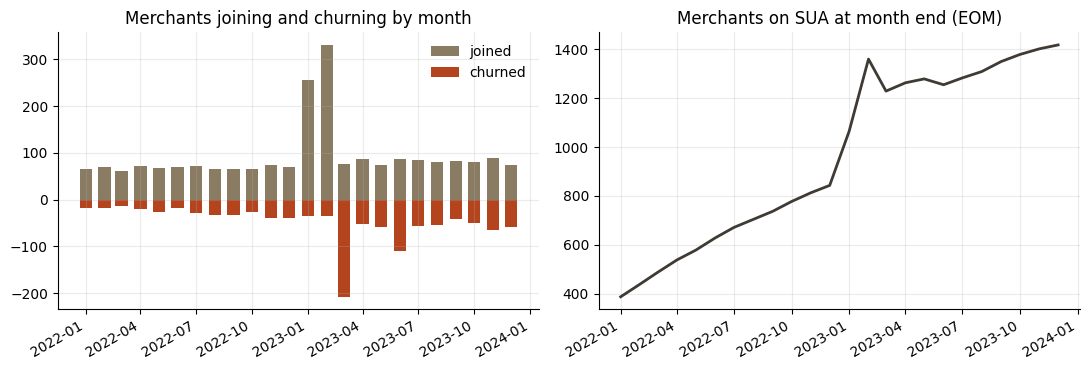

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
x = movement["month"]
ax1.bar(x, movement["joined"], width=20, label="joined", color=SOFT)
ax1.bar(x, -movement["churned"], width=20, label="churned", color=ACCENT)
ax1.set_title("Merchants joining and churning by month")
ax1.legend(frameon=False)
ax2.plot(x, movement["eom"], color=INK, lw=2)
ax2.set_title("Merchants on SUA at month end (EOM)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The chart is the audit trail of the period:

- the **2023-01/02 spike** is an outreach campaign; the **2023-03 churn wave** right after it is the ~30% of those conversions that were wrongful (the payment method was changed without proper merchant consent) and got reverted;
- the smaller **2023-06 step** is the manual churn batch, visible only because the off-log list was unioned in;
- through all of it EOM keeps climbing: acquisition outpaces churn. Whether the *volume* those merchants carry is retained is a different question, and that is what the North Star Metric is for.

## Step 3: marts first, metric second

The production version hit a wall here: Athena caps a query at 100 GB scanned, and the payments table alone blew past it for a year of history. The fix was to model the aggregates with dbt and query the small results, which also meant analysts could self-serve without re-deriving the CDC pairing. Same move here, as two tables:

- `payment_detail_agg`: month x merchant x payment method, with volume and count;
- `merchant_retention_record`: one row per enrollment stint (built in Step 1).


In [6]:
con.execute("""
CREATE OR REPLACE TABLE payment_detail_agg AS
SELECT
    date_trunc('month', paid_at)::DATE AS month,
    merchant_id,
    payment_method,
    sum(amount_usd) AS transaction_volume,
    count(*)        AS transaction_count
FROM payments
GROUP BY 1, 2, 3
""")
con.sql("""
SELECT month, count(*) AS merchant_months,
       round(sum(transaction_volume) / 1e6, 2) AS volume_musd
FROM payment_detail_agg GROUP BY 1 ORDER BY 1 DESC LIMIT 3
""").df()

,month,merchant_months,volume_musd
0,2023-12-01,1076,8.48
1,2023-11-01,1086,8.52
2,2023-10-01,1057,8.57


## Step 4: the North Star Metric, two lenses

For each month M against the cohort three months back (M-3):

- **activity lens**: of merchants who *transacted* in M-3, how many transact in M, and how much of their volume repeats;
- **enrollment lens**: of merchants *enrolled* at M-3, how many are still enrolled at M. This is the "transactable" denominator from the original.

The original computed these with Presto map/array algebra: `map_agg` the volumes per month, `array_intersect` the keys, `reduce` the values back to a sum. An excerpt of what that looked like:

```sql
1e0*cardinality(array_intersect(map_keys(lag(transaction_volume_M, 3) OVER (ORDER BY M)),
                                map_keys(transaction_volume_M))
) / cardinality(map_keys(lag(transaction_volume_M, 3) OVER (ORDER BY M)))
```

It worked, and it was the only way to do it in one pass over a table you could not afford to scan twice. With marts, the same metric is a self-join anyone on the team can read and review. That trade, cleverness for maintainability, is the durable lesson of the project.

In [7]:
nsm = con.sql("""
WITH transacting AS (
    SELECT month, merchant_id, transaction_volume
    FROM payment_detail_agg
    WHERE payment_method = 'Credit Card'
),

transactable AS (                 -- enrolled on the first of the month
    SELECT m.month, r.merchant_id
    FROM (SELECT DISTINCT month FROM transacting) m
    JOIN merchant_retention_record r
      ON r.join_date <= m.month AND r.filled_churn_date > m.month
),

activity AS (                     -- transacted in M-3 -> transacted in M?
    SELECT
        (c.month + INTERVAL 3 MONTH)::DATE                    AS month,
        count(*)                                              AS transacted_m3,
        count(t.merchant_id)                                  AS still_transacting,
        sum(c.transaction_volume)                             AS volume_m3,
        sum(CASE WHEN t.merchant_id IS NOT NULL
                 THEN t.transaction_volume END)               AS volume_retained
    FROM transacting c
    LEFT JOIN transacting t
      ON t.merchant_id = c.merchant_id
     AND t.month = (c.month + INTERVAL 3 MONTH)::DATE
    GROUP BY 1
),

enrollment AS (                   -- enrolled at M-3 -> still enrolled at M?
    SELECT
        (c.month + INTERVAL 3 MONTH)::DATE AS month,
        count(*)                           AS enrolled_m3,
        count(t.merchant_id)               AS still_enrolled
    FROM transactable c
    LEFT JOIN transactable t
      ON t.merchant_id = c.merchant_id
     AND t.month = (c.month + INTERVAL 3 MONTH)::DATE
    GROUP BY 1
)

SELECT
    a.month,
    round(a.still_transacting / a.transacted_m3, 3)      AS retained_merchants_pct,
    round(a.volume_retained   / a.volume_m3, 3)          AS retained_volume_pct,
    round(e.still_enrolled    / e.enrolled_m3, 3)        AS enrollment_retention_pct,
    a.transacted_m3, a.still_transacting,
    round(a.volume_m3 / 1e6, 2)                          AS cohort_volume_musd,
    round(a.volume_retained / 1e6, 2)                    AS retained_volume_musd
FROM activity a
JOIN enrollment e USING (month)
WHERE a.month <= DATE '2023-12-01'
ORDER BY a.month
""").df()
nsm.tail(8)

,month,retained_merchants_pct,retained_volume_pct,enrollment_retention_pct,transacted_m3,still_transacting,cohort_volume_musd,retained_volume_musd
13,2023-05-01,0.651,0.751,0.845,969,631,9.07,6.82
14,2023-06-01,0.642,0.686,0.781,1018,654,9.86,6.76
15,2023-07-01,0.683,0.675,0.835,964,658,9.36,6.32
16,2023-08-01,0.686,0.697,0.836,967,663,9.24,6.44
17,2023-09-01,0.713,0.727,0.840,971,692,8.90,6.47
18,2023-10-01,0.715,0.760,0.892,990,708,8.58,6.53
19,2023-11-01,0.725,0.724,0.889,1001,726,8.62,6.24
20,2023-12-01,0.707,0.767,0.884,1034,731,8.44,6.47


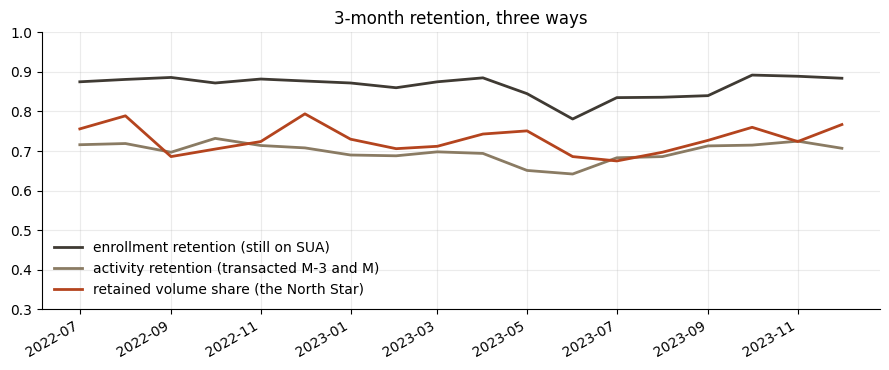

period averages: {'retained_merchants_pct': 0.699, 'retained_volume_pct': 0.73, 'enrollment_retention_pct': 0.865}


In [8]:
recent = nsm[nsm["month"] >= pd.Timestamp("2022-07-01")]
fig, ax = plt.subplots()
ax.plot(recent["month"], recent["enrollment_retention_pct"], lw=2, color=INK,
        label="enrollment retention (still on SUA)")
ax.plot(recent["month"], recent["retained_merchants_pct"], lw=2, color=SOFT,
        label="activity retention (transacted M-3 and M)")
ax.plot(recent["month"], recent["retained_volume_pct"], lw=2, color=ACCENT,
        label="retained volume share (the North Star)")
ax.set_ylim(0.3, 1.0)
ax.set_title("3-month retention, three ways")
ax.legend(frameon=False, loc="lower left")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

avg = recent[["retained_merchants_pct", "retained_volume_pct",
              "enrollment_retention_pct"]].mean().round(3)
print("period averages:", avg.to_dict())

Three numbers that look like one metric until you separate them. Enrollment retention is the healthiest; the activity lens sits far below it; retained volume lands in between, dipping where the wrongful-conversion cohort washes out. The gap between the lenses is not noise, it is segment mix, and the next step shows it.

## Step 5: why the lenses disagree, by segment


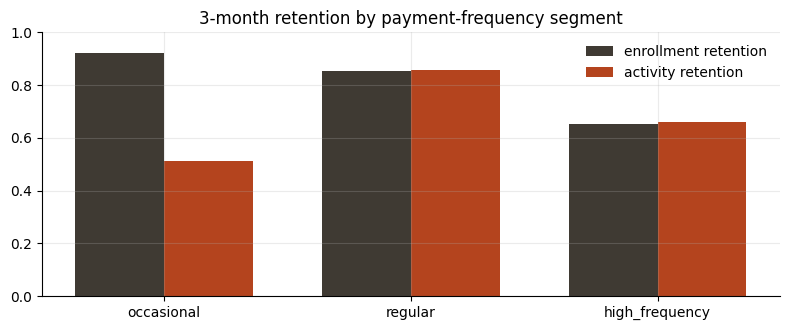

,segment,enrollment_retention,activity_retention
0,occasional,0.920,0.511
1,regular,0.854,0.856
2,high_frequency,0.653,0.659


In [9]:
seg = con.sql("""
WITH transacting AS (
    SELECT month, merchant_id, transaction_volume
    FROM payment_detail_agg WHERE payment_method = 'Credit Card'
),
transactable AS (
    SELECT m.month, r.merchant_id
    FROM (SELECT DISTINCT month FROM transacting) m
    JOIN merchant_retention_record r
      ON r.join_date <= m.month AND r.filled_churn_date > m.month
),
activity AS (
    SELECT mr.segment,
           count(*)             AS transacted_m3,
           count(t.merchant_id) AS still_transacting
    FROM transacting c
    JOIN merchants mr ON mr.merchant_id = c.merchant_id
    LEFT JOIN transacting t
      ON t.merchant_id = c.merchant_id
     AND t.month = (c.month + INTERVAL 3 MONTH)::DATE
    WHERE (c.month + INTERVAL 3 MONTH)::DATE <= DATE '2023-12-01'
    GROUP BY 1
),
enrollment AS (
    SELECT mr.segment,
           count(*)             AS enrolled_m3,
           count(t.merchant_id) AS still_enrolled
    FROM transactable c
    JOIN merchants mr ON mr.merchant_id = c.merchant_id
    LEFT JOIN transactable t
      ON t.merchant_id = c.merchant_id
     AND t.month = (c.month + INTERVAL 3 MONTH)::DATE
    WHERE (c.month + INTERVAL 3 MONTH)::DATE <= DATE '2023-12-01'
    GROUP BY 1
)
SELECT a.segment,
       round(e.still_enrolled / e.enrolled_m3, 3)      AS enrollment_retention,
       round(a.still_transacting / a.transacted_m3, 3) AS activity_retention
FROM activity a JOIN enrollment e USING (segment)
ORDER BY enrollment_retention DESC
""").df()

fig, ax = plt.subplots(figsize=(8, 3.4))
xpos = range(len(seg))
ax.bar([x - 0.18 for x in xpos], seg["enrollment_retention"], width=0.36,
       color=INK, label="enrollment retention")
ax.bar([x + 0.18 for x in xpos], seg["activity_retention"], width=0.36,
       color=ACCENT, label="activity retention")
ax.set_xticks(list(xpos), seg["segment"])
ax.set_ylim(0, 1)
ax.set_title("3-month retention by payment-frequency segment")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
seg

The business read, unchanged from the production analysis:

- **Occasionally paid merchants keep the payment method best.** A card payment twice a quarter means interchange barely registers, so there is no pressure to opt out. Their *activity* retention looks terrible only because they routinely skip months; treating that as churn would misprice the whole program.
- **Frequently paid merchants revert the most.** Interchange and reconciliation effort scale with every payment, so the cost of staying compounds weekly. They carry the largest volumes, which is why volume retention runs below merchant retention.
- This asymmetry is exactly why the North Star divides by the **transactable** (enrollment) denominator: it separates "stopped being paid this month" from "left the program."

## Step 6: is the program still growing where it counts?


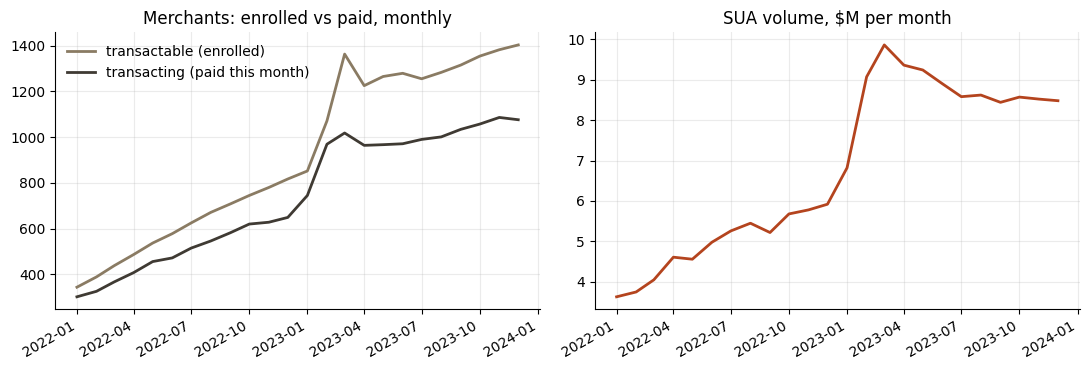

In [10]:
vol = con.sql("""
WITH transacting AS (
    SELECT month, count(DISTINCT merchant_id) AS transacting_merchants,
           sum(transaction_volume)            AS volume
    FROM payment_detail_agg WHERE payment_method = 'Credit Card'
    GROUP BY 1
),
transactable AS (
    SELECT m.month, count(*) AS transactable_merchants
    FROM (SELECT DISTINCT month FROM payment_detail_agg) m
    JOIN merchant_retention_record r
      ON r.join_date <= m.month AND r.filled_churn_date > m.month
    GROUP BY 1
)
SELECT month, transacting_merchants, transactable_merchants,
       round(volume / 1e6, 2) AS volume_musd
FROM transacting JOIN transactable USING (month)
ORDER BY month
""").df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.plot(vol["month"], vol["transactable_merchants"], color=SOFT, lw=2,
         label="transactable (enrolled)")
ax1.plot(vol["month"], vol["transacting_merchants"], color=INK, lw=2,
         label="transacting (paid this month)")
ax1.set_title("Merchants: enrolled vs paid, monthly")
ax1.legend(frameon=False)
ax2.plot(vol["month"], vol["volume_musd"], color=ACCENT, lw=2)
ax2.set_title("SUA volume, $M per month")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Total volume keeps growing even though 3-month retention is imperfect: acquisition adds more volume than churn removes, which was the conclusion the original dashboard existed to defend. The gap between the two merchant lines is the occasional segment not transacting in any given month, not attrition.

## Wrap-up

- The North Star Metric shipped as the **3-month retained SUA volume share**, reported monthly with the enrollment denominator alongside it.
- Everything downstream of the marts was a QuickSight dashboard in the 2022 original; the marts pattern is unchanged today, the dashboard layer would be any business intelligence (BI) tool, and the Presto map/array single-pass trick is retired with honors, replaced by readable joins over dbt models.
- The engineering that survives: dedupe CDC before pairing events, union in what bypassed the log, fill open intervals with the anchor date, and put the metric on denominators that match the question.